In [1]:
import tidy3d as td
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# %matplotlib widget
import hyperspy.api as hs

import os
# api_key = os.environ.get("TIDY3D_API_KEY")

from getpass import getpass
api_key = getpass("Enter your API key: ")

import tidy3d.web as web
# web.configure("_blank_")
web.configure(api_key)

18:03:34 Malay Peninsula Standard Time WARNING: Using canonical configuration   
                                       directory at                             
                                       'C:\Users\Howfishy\.config\tidy3d'. Found
                                       legacy directory at '~/.tidy3d', which   
                                       will be ignored. Remove it manually or   
                                       run 'tidy3d config migrate               
                                       --delete-legacy' to clean up.            

Enter your API key:  ········


Configuration saved successfully.


In [2]:
web.test()


11:43:12 Malay Peninsula Standard Time Authentication configured successfully!

In [2]:
save_dir = '/Users/Howfishy/Documents/0. tidy3d/May10 all gaps/'
os.makedirs(save_dir, exist_ok=True)

In [17]:
import gc
gc.collect()     ####### included to remove files from memory

name = 'y_edge_2_dipolEz_Th100D70G20_vertical_n1_nophase_in_out'
# name = 'dipolEz_Th100D100G200_vertical_n1_nophase' + '_in_out'


sim_data        = td.SimulationData.from_file(f'{save_dir}/{name}.hdf5')
sim0_ref_data   = td.SimulationData.from_file(f'{save_dir}/{name}_empty.hdf5')

####== Check which monitors are present ===###
for monitor in sim_data.simulation.monitors:
    print(monitor.name, monitor.type)

sim_data.simulation.plot_3d()  # visualisation
# sim0_ref_data.simulation.plot_3d()

DFT_in_plane_slice0 FieldMonitor
DFT_in_plane_slice4.5 FieldMonitor
DFT_out_plane FieldMonitor


# Save as csv

In [4]:
h_planck = 6.62607015e-34
e_charge = 1.602176634e-19
def hz_to_ev(f): return (h_planck * f) / e_charge
def ev_to_hz(E): return (E * e_charge) / h_planck

In [5]:
def sum_except_last(arr: np.ndarray):
    """Sum array over all axes except the last one (usually frequency)."""
    return arr if arr.ndim == 0 else arr.sum(axis=tuple(range(arr.ndim - 1)))

# function sum_except_last:
#     Inputs any N-dimensional array, eg.
#         1D: (freq,)
#         2D: (x, freq)
#         3D: (x, y, freq)
#         4D: (x, y, z, freq)
#     sums over all axes except the last one (freq is always preserved)

In [6]:
def compute_normalized_spectrum(sim_data, sim_data0, monitor: str, field: str,
                                hot_pixel_factor=100, eps=1e-18):

    data = getattr(sim_data[monitor], field).values
    ref  = getattr(sim_data0[monitor], field).values

    # energy axis in eV
    freqs_hz = getattr(sim_data[monitor], field).f.values
    freqs_EV = hz_to_ev(freqs_hz)

    # absolute difference per spatial point and frequency
    diff = np.abs(data - ref)  # can be used for point monitor too
    
    # Leaves frequency (last axis) intact:
    diff_total = diff.sum(axis=-1)  # shape (nx,ny) or () for purely point monitors
    
    # Mask to remove hot pixel outliers (anything 100x above median)
    mask = diff_total < (hot_pixel_factor * np.median(diff_total))   
    diff_filtered = diff[mask]
    
    """
    First do absolute difference for each coordinate point, 
    then sums over spatial coordinates (for each frequency)
    normalise by dividing structure/ empty
    """
    
    # Numerator: sum over filtered points (leave frequency axis)
    numerator = sum_except_last(diff_filtered)             # units = V/um

    # Denominator: sum over all spatial points of reference 
    denominator = sum_except_last(np.abs(ref))             # units = V/um

    # normalize (avoid division by zero)
    spectrum_norm = numerator / (denominator + eps)

    return freqs_EV, spectrum_norm, numerator, denominator 

In [42]:
def _align_and_mask(da, da_ref, use_hot_pixel_mask=True, hot_pixel_factor=100):   ### -> **NEW**
    """
    Align two DataArrays to their common frequency grid (inner join),
    then optionally mask spatial outliers (hot pixels).
    """
    da, da_ref = xr.align(da, da_ref, join="inner")
    
    field  = da.values
    ref    = da_ref.values
    freqs_hz = da.coords['f'].values

    scattered = field - ref  # complex scattered field per pixel

    if use_hot_pixel_mask:
        spatial_intensity = np.sum(np.abs(scattered)**2, axis=-1)
        median_val = np.median(spatial_intensity)
        mask = spatial_intensity < (hot_pixel_factor * median_val)
    else:
        mask = np.ones(scattered.shape[:-1], dtype=bool)

    return scattered[mask], ref[mask], freqs_hz
    
    """
    -------
    scat_filtered : np.ndarray  — (n_kept_pixels, n_freq), complex
    ref_filtered  : np.ndarray  — (n_kept_pixels, n_freq), complex
    freqs_hz      : np.ndarray  — 1D frequency array in Hz
    """

def compute_eels_normalized_spectrum(sim_data, sim_data0, monitor, field,                   ### -> **NEW**
                                     hot_pixel_factor=100, use_hot_pixel_mask=True,
                                     eps=1e-18,
                                     smooth=True, smoothing_window=5,
                                     verbose=False):

    # ── 1. Load fields and align to common grid ────────────────────────────────
    da     = getattr(sim_data [monitor], field).drop_duplicates(dim='f')
    da_ref = getattr(sim_data0[monitor], field).drop_duplicates(dim='f')

    scat_filtered, ref_filtered, freqs_hz = _align_and_mask(
        da, da_ref, use_hot_pixel_mask, hot_pixel_factor
    )
    freqs_ev = hz_to_ev(freqs_hz)

    if verbose:
        print(f"[{field}@{monitor}] scat shape: {scat_filtered.shape}, "
              f"ref shape: {ref_filtered.shape}, n_freq: {len(freqs_ev)}")

    # ── 2. Per-pixel susceptibility χ(ω) = ΔE / E_ref ─────────────────────────
    # Dividing per-pixel (not summing first) prevents destructive interference
    # across pixels that are larger than one wavelength apart.
    denom_mag = np.abs(ref_filtered)
    valid     = denom_mag > eps

    chi_spatial          = np.zeros_like(scat_filtered, dtype=complex)
    chi_spatial[valid]   = scat_filtered[valid] / ref_filtered[valid]

    # Spatial average → χ̄(ω), shape (n_freq,)
    spatial_axes = tuple(range(chi_spatial.ndim - 1))
    chi = np.mean(chi_spatial, axis=spatial_axes)

    # ── 3. Dielectric function and loss function ───────────────────────────────
    epsilon     = 1.0 + chi                     # ε(ω) = 1 + χ̄(ω)

    valid_eps   = np.abs(epsilon) > eps
    epsilon_inv = np.zeros_like(epsilon, dtype=complex)
    epsilon_inv[valid_eps] = 1.0 / epsilon[valid_eps]

    loss_function = np.maximum(-np.imag(epsilon_inv), 0)   # clamp: loss ≥ 0

    if verbose:
        print(f"  chi  |mean|={np.mean(np.abs(chi)):.3e}")
        print(f"  ε    range : {epsilon.min():.3e} – {epsilon.max():.3e}")
        print(f"  loss range : {loss_function.min():.3e} – {loss_function.max():.3e}")

    # ── 4. Optional smoothing ──────────────────────────────────────────────────
    if smooth and len(loss_function) > smoothing_window:
        if smoothing_window % 2 == 0:
            smoothing_window += 1
        loss_function = np.maximum(
            signal.savgol_filter(loss_function, smoothing_window, polyorder=2), 0
        )

    # ── 5. Energy-binning correction + area normalisation ─────────────────────
    energy_binning = np.gradient(freqs_ev)       # Δ(eV) per bin
    eels_spectrum  = loss_function / energy_binning   # units: 1/eV

    integral = np.trapezoid(eels_spectrum, freqs_ev)
    if np.isfinite(integral) and integral > 1e-25:
        eels_normalized = eels_spectrum / integral
    else:
        if verbose:
            print(f"  [WARN] integral={integral:.3e} too small; returning unnormalised spectrum")
        eels_normalized = eels_spectrum

    return freqs_ev, eels_normalized
    """
    -------
    freqs_ev       : np.ndarray, shape (n_freq,)  — energy axis in eV
    eels_normalized: np.ndarray, shape (n_freq,)  — area-normalised EELS spectrum (1/eV)
    """

In [45]:
def save_all_spectra(sim_data, sim_data0, 
                     monitors, 
                     fields=('Ex','Ey','Ez','Hx','Hy','Hz',), 
                     out_dir='data/spectra'):
    
    # Save_as_csv for all monitors/fields spectra (with compute_normalized_spectrum())
    os.makedirs(out_dir, exist_ok=True)
    
    rows = []
    for mon in monitors:
        for field in fields:
            ###################################
            #################   NEW ###########        |eels_normalized_spectrum
            if 'withphase' in name:
                freqs_ev, spectrum, num, den = compute_eels_normalized_spectrum(sim_data, sim_data0, monitor=monitor, field=field)  ## **New**
            
            elif 'nophase' in name:
            # else:    # all other simulations not just (elif 'nophase' in name:)
                freqs_ev, spectrum, num, den = compute_normalized_spectrum(sim_data, sim_data0, monitor=monitor, field=field)  ## simple normalization
            else:
                raise ValueError(f"Cannot determine spectrum method from name: '{name}'. "
                                 f"Expected 'nophase' or 'withphase' in the name string.")
            ###################################

            ####====== Default ============#####################
            # freqs_ev, spec_norm, num, den = compute_normalized_spectrum(sim_data, sim_data0, mon, field)  #### Default
            ##############=================#####################
            
            df = pd.DataFrame({'eV': freqs_ev, 'spectrum': spec_norm})   # per-monitor-field CSV
            fname = os.path.join(out_dir, f"{field}_{mon}_spectrum.csv")
            df.to_csv(fname, index=False)
            
            # also store stacked rows for a combined CSV
            for ev, val in zip(freqs_ev, spec_norm):
                rows.append({'monitor': mon, 'field': field, 'eV': ev, 'spectrum': val})
                
    combined = pd.DataFrame(rows)
    combined.to_csv(os.path.join(out_dir, "all_spectra_combined.csv"), index=False)
    
    print(f"FInished saving individual CSVs to {out_dir} and combined CSV.")

# Peak fitting

In [8]:
from scipy.signal import find_peaks, peak_widths
from scipy.optimize import curve_fit
from scipy.special import wofz # for voight

# Gaussian: amplitude A (height), center x0, sigma (std dev)
def gaussian_single(x, A, x0, sigma):
    return A * np.exp(-((x - x0)**2) / (2 * sigma**2))

# Lorentzian: amplitude A (height), center x0, gamma (HWHM)
def lorentzian_single(x, A, x0, gamma):
    return A * (gamma**2) / ((x - x0)**2 + gamma**2)

# Voigt via real(wofz) normalized kernel, scaled by A
def voigt_profile_norm(x, sigma, gamma):
    # normalized Voigt profile (area normalized)
    z = (x + 1j * gamma) / (sigma * np.sqrt(2))
    return np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi))

def voigt_single(x, A, x0, sigma, gamma):
    return A * voigt_profile_norm(x - x0, sigma, gamma)


In [9]:
def detect_peaks_on_spectrum(freqs_ev, spectrum, rel_prominence=0.05, min_distance_ev=None):
    """
    # Initial guesses
    # Find peaks in `spectrum` (1D). Returns peak indices and widths (FWHM estimate).
    default = rel_prominence: uses fraction of max(spectrum)
    """
    prominence = rel_prominence * np.nanmax(spectrum)
    
    # convert min_distance_ev to samples if provided
    if min_distance_ev is not None:
        delta = np.abs(freqs_ev[1] - freqs_ev[0])
        min_distance_samples = max(1, int(min_distance_ev / delta))
    else:
        min_distance_samples = None

    peaks, prop = find_peaks(spectrum, prominence=prominence, distance=min_distance_samples)
    
    # widths in number of samples at half prominence; convert to eV
    widths_res = peak_widths(spectrum, peaks, rel_height=0.5)
    widths_samples = widths_res[0]
    delta = np.abs(freqs_ev[1] - freqs_ev[0])
    widths_ev = widths_samples * delta

    results = []
    
    # # Calculate peak area using trapezoidal integration               #### Not used
    # # Use the detected width to define integration bounds
    # half_width_samples = int(widths_samples[i] / 2)
    # left_idx = max(0, p - half_width_samples)
    # right_idx = min(len(spectrum) - 1, p + half_width_samples)
    
    # # Subtract baseline (minimum value in the range)
    # baseline = np.min(spectrum[left_idx:right_idx+1])
    # peak_area = np.trapz(spectrum[left_idx:right_idx+1] - baseline, 
    #                     freqs_ev[left_idx:right_idx+1])
    
    for i, p in enumerate(peaks):
        results.append({
            'peak_index' : int(p),
            'peak_eV'    : float(freqs_ev[p]),
            'peak_height': float(spectrum[p]),
            'width_eV'   : float(widths_ev[i]),
            'prominence' : float(prop['prominences'][i]),
            # 'area': float(peak_area)                                    #### Not used
        })
    
    return results

In [10]:
def fit_single_peak_local(freqs, 
                          spectrum, 
                          peak_eV, 
                          window_half_width_eV=10,
                          model='lorentzian',
                          min_points=10):
    """
    Fit a single peak centered near peak_eV using a local window.
    model in ['lorentzian', 'gaussian', 'voigt'].
    Returns fit parameters and the fitted curve on the local x grid.
    """

    # Start with the requested window
    current_window = window_half_width_eV
    
    # Try expanding the window until we have enough points
    for attempt in range(5):
        mask = (freqs >= (peak_eV - current_window)) & (freqs <= (peak_eV + current_window))
        x = freqs[mask]
        y = spectrum[mask]
        if len(x) >= min_points:  # check if at least 10 points 
            break
        current_window *= 1.5
        
    if len(x) < min_points:
        return {'error': f'Not enough points: {len(x)}, need {min_points}'}

    # initial guesses
    A0 = np.max(y)
    x0 = peak_eV
    dx = x[1] - x[0]
    sigma0 = max( (window_half_width_eV / 4), dx*2 )   # crude
    gamma0 = sigma0

    try:
        if model == 'lorentzian':
            p0 = [A0, x0, gamma0]
            popt, pcov = curve_fit(lorentzian_single, x, y, p0=p0, maxfev=20000)
            A_fit, x0_fit, gamma_fit = popt
            fwhm = 2.0 * gamma_fit
            fitted = lorentzian_single(x, *popt)
            params = {'A':A_fit, 'x0':x0_fit, 'gamma':gamma_fit, 'FWHM':fwhm}
        
        elif model == 'gaussian':
            p0 = [A0, x0, sigma0]
            popt, pcov = curve_fit(gaussian_single, x, y, p0=p0, maxfev=20000)
            A_fit, x0_fit, sigma_fit = popt
            # FWHM for Gaussian
            fwhm = 2.0 * np.sqrt(2*np.log(2)) * sigma_fit
            fitted = gaussian_single(x, *popt)
            params = {'A':A_fit, 'x0':x0_fit, 'sigma':sigma_fit, 'FWHM':fwhm}

        elif model == 'voigt':
            p0 = [A0, x0, sigma0, gamma0]
            popt, pcov = curve_fit(voigt_single, x, y, p0=p0, maxfev=20000)
            A_fit, x0_fit, sigma_fit, gamma_fit = popt
            
            # approximate FWHM for Voigt (Olivero and Longbothum approximation)
            fwhm = 0.5346 * (2*gamma_fit) + np.sqrt(0.2166 * (2*gamma_fit)**2 + (2.35482 * sigma_fit)**2)
            fitted = voigt_single(x, *popt)
            params = {'A':A_fit, 'x0':x0_fit, 'sigma':sigma_fit, 'gamma':gamma_fit, 'FWHM':fwhm}

        else:
            raise ValueError("model must be 'lorentzian', 'gaussian' or 'voigt'")

        # compute residual sum of squares
        rss = np.sum((y - fitted)**2)
        params.update({'rss':float(rss)})
        return {'x':x, 'y':y, 'fitted':fitted, 'params':params}

    except Exception as e:
        # fitting failed
        return {'error': str(e)}


In [11]:
def fit_and_save_all(sim_data, sim_data0, monitors, fields=('Ex','Ez'),
                     out_dir='data/peak_fits', 
                     window_half_width_eV=5, 
                     n_peaks_max=6):
    import pandas as pd
    os.makedirs(out_dir, exist_ok=True)
    
    all_fit_rows = []
    for mon in monitors:
        for field in fields:
            freqs_ev, spec_norm, _, _ = compute_normalized_spectrum(sim_data, sim_data0, mon, field)
            
            peaks = detect_peaks_on_spectrum(freqs_ev, spec_norm, rel_prominence=0.05) # detect peaks
            
            if len(peaks) > n_peaks_max:                           # optionally limit number of peaks to 6
                peaks = sorted(peaks, key=lambda r: r['peak_height'], reverse=True)[:n_peaks_max]

            # for each peak try the three models and save results
            for pk in peaks:
                center = pk['peak_eV']
                for model in ['lorentzian', 
                              'gaussian',              # can remove saving gaussian data results
                              'voigt'                  # can remove saving voigt data results
                             ]:
                    res = fit_single_peak_local(freqs_ev, spec_norm, center,
                                                window_half_width_eV=window_half_width_eV,
                                                model=model)
                    row = {
                        'monitor': mon, 
                        'field'  : field, 
                        'model'  : model,
                        'initial_peak_eV': center
                    }
                    if res is None:
                        row.update({'fit_status': 'not_enough_points'})
                    elif 'error' in res:
                        row.update({'fit_status': 'error', 'error': res['error']})
                    else:
                        p = res['params']
                        row.update({
                            'fit_status'      : 'ok',
                            'fitted_center_eV': p['x0'],
                            'height'          : p['A'],
                            'FWHM_eV'         : p['FWHM'],
                            'rss'             : p['rss'],
                            'Q_factor'        : p['x0'] / p['FWHM'],   # <-- **NEW** added this
                        })
                        
                        # Save fitted curve for this peak to a small CSV
                        df_fit = pd.DataFrame({'eV': res['x'], 'data': res['y'], 'fit': res['fitted']})
                        # fname = os.path.join(out_dir, f"{field}_peak_{center:.4f}eV_{mon}_{model}.csv")
                        fname = os.path.join(out_dir, f"{p['x0']:.1f}eV_{field}_peak_{mon}_{model}.csv"
                                            ) # use 'fitted_center_eV' instead of 'initial_peak_eV'
                        df_fit.to_csv(fname, index=False)
                    all_fit_rows.append(row)

    df_all = pd.DataFrame(all_fit_rows)
    df_all.to_csv(os.path.join(out_dir, name+"all_peak_fits_summary.csv"), index=False)
    print("Saved peak fit results to", out_dir)


# Execute

In [12]:
monitors = [
# 'DFT_in_plane_slice0',
'DFT_in_plane_slice0',
# 'DFT_in_plane_slice1',
# 'DFT_in_plane_slice2',
# 'DFT_in_plane_slice3',
'DFT_in_plane_slice4.5',

'DFT_out_plane',
    
# 'DFT_bottom_plane_slice0.5',
# 'DFT_bottom_plane_slice2',
# 'DFT_bottom_plane_slice4',
# 'DFT_bottom_plane_slice8',
# 'DFT_bottom_plane_slice14',

# 'DFT_in_plane_Left',
# 'DFT_in_plane_Right',

# 'DFT_ZX_plane_n1',
# 'DFT_ZX_plane_n2',
# 'DFT_ZY_plane_n1',
# 'DFT_ZY_plane_n2',
]

In [18]:
# ##### ============ #####   Generate all csv files ##### =========================
###################################################################################
save_all_spectra(sim_data, sim0_ref_data, monitors, fields=('Ex','Ez','Ey'), out_dir=f'data_{name}/spectraE')


###################################################################################
###################################################################################

FInished saving individual CSVs to data_y_edge_2_dipolEz_Th100D70G20_vertical_n1_nophase_in_out/spectraE and combined CSV.


In [19]:
###################################################################################
###################################################################################
save_all_spectra(sim_data, sim0_ref_data, monitors, fields=('Hx','Hz','Hy'), out_dir=f'data_{name}/spectraH')


###################################################################################
###################################################################################

FInished saving individual CSVs to data_y_edge_2_dipolEz_Th100D70G20_vertical_n1_nophase_in_out/spectraH and combined CSV.


In [20]:
# ##### ============ #####   Saving peak-detailed data ##### =========================
###################################################################################
fit_and_save_all(sim_data, sim0_ref_data, monitors, fields=('Ex','Ez','Ey', ),
                     out_dir=f'data_{name}/peak_fitsE', window_half_width_eV=0.2, n_peaks_max=6)

fit_and_save_all(sim_data, sim0_ref_data, monitors, fields=('Hx','Hz','Hy' ),
                     out_dir=f'data_{name}/peak_fitsH', window_half_width_eV=0.2, n_peaks_max=6)


###################################################################################
###################################################################################

Saved peak fit results to data_y_edge_2_dipolEz_Th100D70G20_vertical_n1_nophase_in_out/peak_fitsE
Saved peak fit results to data_y_edge_2_dipolEz_Th100D70G20_vertical_n1_nophase_in_out/peak_fitsH


# Something New

In [21]:
# ── COnfig file  ───────────────────────

# Field order within each group (top to bottom in the plot)
GROUP_A_FIELDS = ['Ez', 'Hx', 'Hy']   # rows top→bottom
GROUP_B_FIELDS = ['Hz', 'Ex', 'Ey']

# Monitor → marker style. Add/remove monitors here as your runs change.
# 'keyword' is a substring matched against the full monitor name.
MONITOR_STYLES = {
    'slice0'   : dict(marker='|',  color='cornflowerblue',  markersize=12, markeredgewidth=3,  label='slice0',  zorder=3),
    'slice4.5' : dict(marker='|',  color='mediumturquoise', markersize=12, markeredgewidth=3, label='slice4.5', zorder=3),
    'out_plane': dict(marker='o',  color='black',         markersize=8,  label='out_plane', zorder=3),
}

BIN_WIDTH_EV = 1.0    # coincidence tolerance
PROMINENCE   = 0.05   # rel_prominence for detect_peaks_on_spectrum

In [22]:
def get_monitor_style(monitor_name):
    """Match monitor name against MONITOR_STYLES keywords, first match wins."""
    for keyword, style in MONITOR_STYLES.items():
        if keyword in monitor_name:
            return style
    # fallback if nothing matches
    return dict(marker='D', color='gray', markersize=7, label=monitor_name, zorder=3)

In [56]:
def make_strip_chart(group_a_fields, group_b_fields, monitors,
                     peaks_cache, bin_width=1.0):
    # ── Spacing constants ──────────────────────────────────────────────────────
    MONITOR_SPACING = 0.55   # between monitors within the same field (tight)
    FIELD_SPACING   = 1.2    # between different fields
    DIVIDER_EXTRA   = 1.6    # extra gap between Group A and Group B
    BOLD_FIELDS     = {'Ez', 'Hz'}   # fields to bold on y-axis
    
    # Build the full ordered row list:
    # Group A fields × monitors, divider, Group B fields × monitors
    def rows_for_group(fields):
        return [(field, mon) for field in fields for mon in monitors]

    rows_A = rows_for_group(group_a_fields)
    rows_B = rows_for_group(group_b_fields)
    all_rows = rows_A + [None] + rows_B   # None = used as a divider slot

    # ── Assign y_positions with variable spacing ───────────────────────────────
    # ROW_SPACING  = 1.0    # y positions: uniform spacing, extra gap at divider
    # DIVIDER_EXTRA = 1.2   # extra vertical space for the divider gap

    y_positions = {}
    y = 0.0
    prev_field = None

    for row in reversed(all_rows):
        if row is None:
            y += DIVIDER_EXTRA
            prev_field = None
            continue
        field, mon = row
        if prev_field is not None and field != prev_field:
            y += FIELD_SPACING      # gap when field changes
        else:
            y += MONITOR_SPACING    # tight gap within same field
        y_positions[row] = y
        prev_field = field

    total_height = y

    # ── Figure ────────────────────────────────────────────────────────────────
    plt.close('all')
    n_rows = len([r for r in all_rows if r is not None])
    fig_height = max(6, 0.45 * n_rows)
    fig, ax = plt.subplots(figsize=(12, fig_height))

    # ── Y-axis tick labels ─────────────────────────────────────────────────────
    ytick_pos    = [y_positions[r] for r in all_rows if r is not None]
    ytick_labels = [r[0] for r in all_rows if r is not None]   # field name

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels([])   # we'll draw manually for bold control

    for row in [r for r in all_rows if r is not None]:
        field, mon = row
        yp = y_positions[row]
        weight = 'bold' if field in BOLD_FIELDS else 'normal'
        # only label once per (field, monitor) — label is always the field name
        ax.text(-0.05, yp, field,
                transform=ax.get_yaxis_transform(),
                ha='right', va='center',
                fontsize=10, fontweight=weight)

    # Light horizontal grid lines for each row ─────────────────────────────────
    for yp in ytick_pos:
        ax.axhline(yp, color='#e0e0e0', lw=0.6, zorder=0)
    
    # ── Vertical x grid lines (faint) ─────────────────────────────────────────
    for xv in np.arange(0, 23, 2):
        ax.axvline(xv, color='#ececec', lw=0.6, zorder=0)

    # ── Divider line ───────────────────────────────────────────────────────────
    # sits between the last row of A and first row of B
    last_A_y  = y_positions[rows_A[-1]]
    first_B_y = y_positions[rows_B[0]]
    divider_y = (last_A_y + first_B_y) / 2
    ax.axhline(divider_y, color='#999999', lw=1.2, ls='--', zorder=1)

    # ──── Group labels on the right margin ──────────────────────────────────────
    group_A_center = np.mean([y_positions[r] for r in rows_A])
    group_B_center = np.mean([y_positions[r] for r in rows_B])
    # ax.text(22.5, group_A_center, 'Ez / Hx / Hy',
    #         va='center', ha='left', fontsize=9, color='#444444',
    #         rotation=90)
    # ax.text(22.5, group_B_center, 'Hz / Ex / Ey',
    #         va='center', ha='left', fontsize=9, color='#444444',
    #         rotation=90)
    for yc, txt in [(group_A_center, 'Ez / Hx / Hy'),
                    (group_B_center, 'Hz / Ex / Ey')]:
        ax.text(1.01, yc, txt,
                transform=ax.get_yaxis_transform(),
                va='center', ha='left', fontsize=8.5,
                color='#555555', rotation=90)

    # ── Monitor name annotations to the left of each row block ────────────────
    # Label the monitor once per field-group boundary
    # Use figure transform so they sit at a fixed left margin regardless of data
    # for field in group_a_fields + group_b_fields:
    #     for mon in monitors:
    #         row = (field, mon)
    #         style = get_monitor_style(mon)
    #         yp    = y_positions[row]
            
    #         # small monitor label to the right of the y-axis label
    #         ax.text(-0.8, yp, f'[{mon.replace("DFT_","").replace("_plane","").replace("in_","")}]',
    #                 fontsize=6.5, color=style['color'], va='center', ha='right',
    #                 transform=ax.get_yaxis_transform())
    for row in [r for r in all_rows if r is not None]:
        field, mon = row
        style  = get_monitor_style(mon)
        yp     = y_positions[row]
        # short label: strip DFT_ prefix and _plane suffix
        short = (mon.replace('DFT_', '')
                    .replace('in_plane_', '')
                    .replace('_plane', ''))
        ax.text(-0.10, yp, f'[{mon.replace("DFT_","").replace("_plane","").replace("in_","")}]',
                va='center', ha='right',
                transform=ax.get_yaxis_transform(),
                fontsize=7, color=style['color'])

    # ── Plot peaks ────────────────────────────────────────────────────────────
    for row in [r for r in all_rows if r is not None]:
        field, monitor = row
        style    = get_monitor_style(monitor)
        yp       = y_positions[row]
        plot_kw  = {k: v for k, v in style.items() if k != 'label'}
        for pk in peaks_cache[row]:
            # ax.plot(pk['peak_eV'], yp, linestyle='none', **plot_kw)

            plot_kw = {k: v for k, v in style.items() if k != 'label'}   ## **New**
            q = pk.get('q_factor')
            if q is not None and q > 5:
                plot_kw['color'] = 'magenta'
            elif q is not None and q > 3.5:
                plot_kw['color'] = 'orangered'
            ax.plot(pk['peak_eV'], yp, linestyle='none', **plot_kw)

    # ── X axis ────────────────────────────────────────────────────────────────
    ax.set_xlim(0, 22)
    ax.set_xticks(np.arange(0, 23, 2))
    ax.set_xlabel('Energy (eV)', fontsize=11)
    ax.set_ylim(y_positions[rows_B[-1]] - 0.8, 
            y_positions[rows_A[0]] + 0.8)
    # ax.set_ylim(y_positions[rows_A[0]] - 0.8,
    #             y_positions[rows_B[-1]] + 0.8)

    # ── Legend (monitor styles) ────────────────────────────────────────────────
    legend_handles = []

    legend_handles.append(plt.Line2D([0],[0], linestyle='none', marker='o',
                                  color='orangered', markersize=7, label='Q > 3.5'))  ## **New**
    legend_handles.append(plt.Line2D([0],[0], linestyle='none', marker='o',
                                  color='magenta',   markersize=7, label='Q > 5'))
    for keyword, style in MONITOR_STYLES.items():
        # only include monitors actually present in this run
        if any(keyword in mon for mon in monitors):
            h = plt.Line2D([0], [0], linestyle='none',
                           marker=style['marker'],
                           color=style['color'],
                           markersize=style['markersize'],
                           markeredgewidth=style.get('markeredgewidth', 1.5),
                           label=style['label'])
            legend_handles.append(h)
    ax.legend(handles=legend_handles, 
              # loc='upper left',
              loc='upper center',          # The anchor point on the legend itself
              bbox_to_anchor=(0.5, -0.08), # (x, y) coordinates relative to the axes
              ncol=3,                      # Spread items horizontally (optional but recommended)
              fontsize=9, framealpha=0.85, title='Monitor')

    ax.set_title(f'Peak positions — {name}', fontsize=11, pad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(left=False)   # hide left tick marks since we draw labels manually
    plt.subplots_adjust(left=0.18) # Tighten left margin so sub-labels aren't marooned in whitespace
    # plt.tight_layout()

    plt.show()

    fig_path = os.path.join(f'data_{name}', f'{name}_peak_strip_chart.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {fig_path}")

## Execute something new

In [30]:
##### Store data as cache to allow _make_strip_chart to run faster
from collections import defaultdict

# All unique (field, monitor) pairs we actually need
all_fields   = list(dict.fromkeys(GROUP_A_FIELDS + GROUP_B_FIELDS))  # preserve order, deduplicate
all_pairs    = [(field, mon) for field in all_fields for mon in monitors]

spectra_cache = {}   # (field, monitor) -> (freqs_ev, spec_norm)
peaks_cache   = {}   # (field, monitor) -> list of peak dicts

# for (field, monitor) in all_pairs:
#     freqs_ev, spec_norm, _, _ = compute_normalized_spectrum(sim_data, sim0_ref_data, monitor, field )
#     spectra_cache[(field, monitor)] = (freqs_ev, spec_norm)
#     peaks_cache[(field, monitor)]   = detect_peaks_on_spectrum(
#         freqs_ev, spec_norm, rel_prominence=PROMINENCE
#     )

for (field, monitor) in all_pairs:
    freqs_ev, spec_norm, _, _ = compute_normalized_spectrum(
        sim_data, sim0_ref_data, monitor, field
    )
    spectra_cache[(field, monitor)] = (freqs_ev, spec_norm)
    raw_peaks = detect_peaks_on_spectrum(freqs_ev, spec_norm, rel_prominence=PROMINENCE)
    
    for pk in raw_peaks:
        res = fit_single_peak_local(freqs_ev, spec_norm, pk['peak_eV'],
                                    window_half_width_eV=0.2, model='lorentzian')
        if 'params' in res and res['params']['FWHM'] > 0:
            pk['q_factor'] = res['params']['x0'] / res['params']['FWHM']
        else:
            pk['q_factor'] = None
    
    peaks_cache[(field, monitor)] = raw_peaks

print(f"Computed {len(all_pairs)} (field, monitor) pairs.")

Computed 18 (field, monitor) pairs.


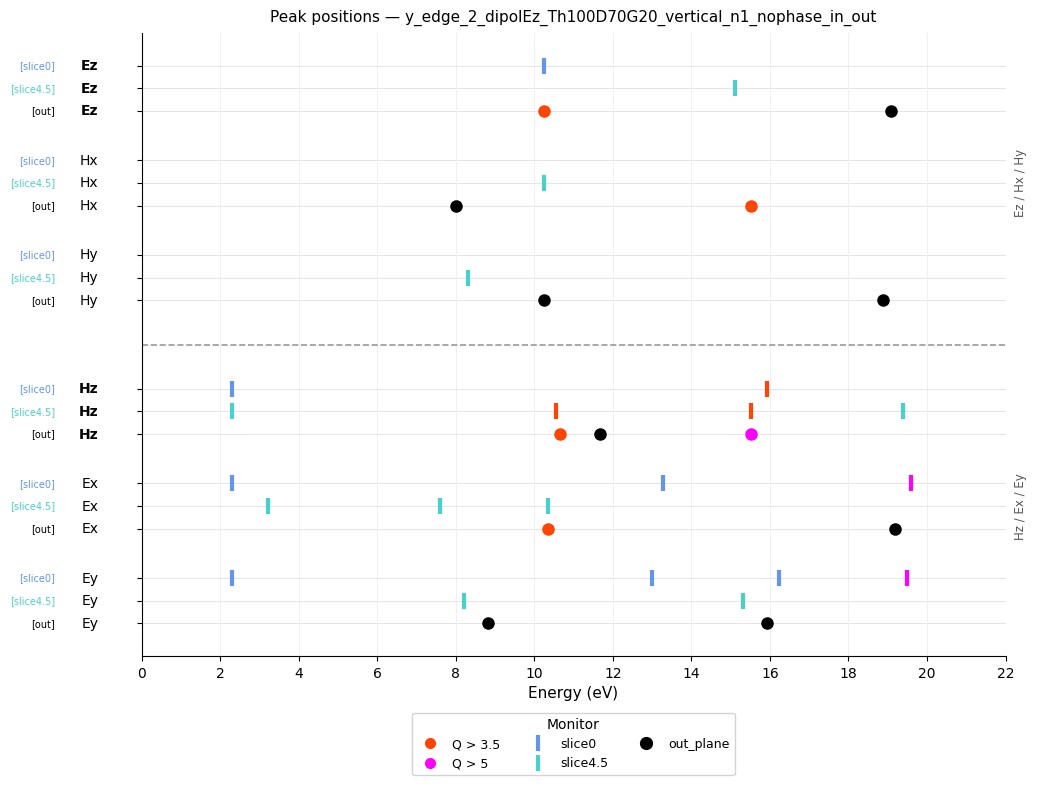

Saved to data_y_edge_2_dipolEz_Th100D70G20_vertical_n1_nophase_in_out\y_edge_2_dipolEz_Th100D70G20_vertical_n1_nophase_in_out_peak_strip_chart.png


In [57]:
###################################################################################
####################    Dot plot / strip-chart   ###################################
###################################################################################

make_strip_chart(GROUP_A_FIELDS, GROUP_B_FIELDS, monitors,peaks_cache, bin_width=BIN_WIDTH_EV)

###################################################################################
###################################################################################